# Micro Proyecto 1 · v4 — LSTM con Embeddings Discretos por Atributo

**Compositor:** Ludwig van Beethoven  
**Modelo:** LSTM 3 capas · embeddings separados por atributo · 4 cabezas de clasificación  
**Diferencias respecto a v3:**
- Representación completamente discreta: 4 índices enteros por nota (pitch reindexado, velocity/step/duration en bins)
- 4 embeddings separados (dim 16+4+8+8 = 36) en lugar de un embedding+floats
- Split por obra completa (sin fuga de datos train↔val↔test)
- Velocity también discreta: CrossEntropyLoss en las 4 salidas
- Loss total = 2·pitch + velocity + step + duration
- Perplexity y accuracy por cada cabeza
- Generación: argmax (determinista) o muestreo con temperatura configurable


In [1]:
# ── Bandera de entorno ───────────────────────────────────────────────────
# False → corre en local con los paths relativos del repo
# True  → corre en Google Colab con Google Drive montado
COLAB = True

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install pretty_midi
    


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 82.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.9 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=c1e888a94e547e30138b70793aab67fe6dd2b2e7f0ef83d773903327cef50ee0
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [2]:
import pretty_midi
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from collections import defaultdict, Counter

np.random.seed(42)
torch.manual_seed(42)


## 1. Leer los archivos MIDI de Beethoven


In [3]:
if COLAB:
    DATA_PATH = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/data/music_artist/beeth'
else:
    DATA_PATH = './data/music_artist/beeth'

midi_files = sorted([os.path.join(DATA_PATH, f)
                     for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos encontrados: {len(midi_files)}')
for i, f in enumerate(midi_files):
    print(f'  [{i}] {os.path.basename(f)}')


Archivos encontrados: 29
  [0] appass_1.mid
  [1] appass_2.mid
  [2] appass_3.mid
  [3] beethoven_hammerklavier_1.mid
  [4] beethoven_hammerklavier_2.mid
  [5] beethoven_hammerklavier_3.mid
  [6] beethoven_hammerklavier_4.mid
  [7] beethoven_les_adieux_1.mid
  [8] beethoven_les_adieux_2.mid
  [9] beethoven_les_adieux_3.mid
  [10] beethoven_opus10_1.mid
  [11] beethoven_opus10_2.mid
  [12] beethoven_opus10_3.mid
  [13] beethoven_opus22_1.mid
  [14] beethoven_opus22_2.mid
  [15] beethoven_opus22_3.mid
  [16] beethoven_opus22_4.mid
  [17] beethoven_opus90_1.mid
  [18] beethoven_opus90_2.mid
  [19] elise.mid
  [20] mond_1.mid
  [21] mond_2.mid
  [22] mond_3.mid
  [23] pathetique_1.mid
  [24] pathetique_2.mid
  [25] pathetique_3.mid
  [26] waldstein_1.mid
  [27] waldstein_2.mid
  [28] waldstein_3.mid


## 2. Explorar un archivo


In [4]:
pm = pretty_midi.PrettyMIDI(midi_files[0])
print(f'Archivo:    {os.path.basename(midi_files[0])}')
print(f'Duración:   {pm.get_end_time():.1f} s')
print(f'Instrumentos: {len(pm.instruments)}')
for i, inst in enumerate(pm.instruments):
    name = pretty_midi.program_to_instrument_name(inst.program)
    print(f'  [{i}] {name} — {len(inst.notes)} notas')


Archivo:    appass_1.mid
Duración:   558.9 s
Instrumentos: 2
  [0] Acoustic Grand Piano — 3207 notas
  [1] Acoustic Grand Piano — 3170 notas


## 3. Extraer las características de todos los archivos

Por cada nota extraemos: **pitch** (entero), **step** (tiempo desde nota anterior),
**duration** (duración) y **velocity** (intensidad).  
Cada archivo puede aportar 1 o 2 secuencias de piano; ambas se incluyen.


In [5]:
TARGET_INSTRUMENT = 'Acoustic Grand Piano'

def extract_notes(instrument):
    notes = sorted(instrument.notes, key=lambda x: x.start)
    rows, prev_start = [], None
    for note in notes:
        duration  = note.end - note.start
        step      = note.start - prev_start if prev_start is not None else 0.0
        rows.append({'pitch': note.pitch, 'step': step,
                     'duration': duration, 'velocity': note.velocity})
        prev_start = note.start
    return rows

sequences      = []  # lista de DataFrames
sequence_names = []  # 'archivo.mid — inst N'

for mid, f in enumerate(midi_files):
    pm = pretty_midi.PrettyMIDI(f)
    for i, instrument in enumerate(pm.instruments):
        if pretty_midi.program_to_instrument_name(instrument.program) != TARGET_INSTRUMENT:
            continue
        notes = extract_notes(instrument)
        sequences.append(pd.DataFrame(notes))
        sequence_names.append(f'{os.path.basename(f)} — inst {i}')

df_all = pd.concat(sequences, ignore_index=True)
print(f'Total de secuencias: {len(sequences)}')
print(f'Total de notas:      {len(df_all):,}')


Total de secuencias: 47
Total de notas:      84,785


## 4. Análisis Exploratorio (EDA)


Archivo                                       Seqs
----------------------------------------------------
  appass_1.mid                                2
  appass_2.mid                                2
  appass_3.mid                                2
  beethoven_hammerklavier_1.mid               2
  beethoven_hammerklavier_2.mid               2
  beethoven_hammerklavier_3.mid               2
  beethoven_hammerklavier_4.mid               2
  beethoven_les_adieux_1.mid                  2
  beethoven_les_adieux_2.mid                  2
  beethoven_les_adieux_3.mid                  2
  beethoven_opus10_1.mid                      2
  beethoven_opus10_2.mid                      2
  beethoven_opus10_3.mid                      2
  beethoven_opus22_1.mid                      2
  beethoven_opus22_2.mid                      2
  beethoven_opus22_3.mid                      2
  beethoven_opus22_4.mid                      2
  beethoven_opus90_1.mid                      2
  beethoven_opus90_2.mid        

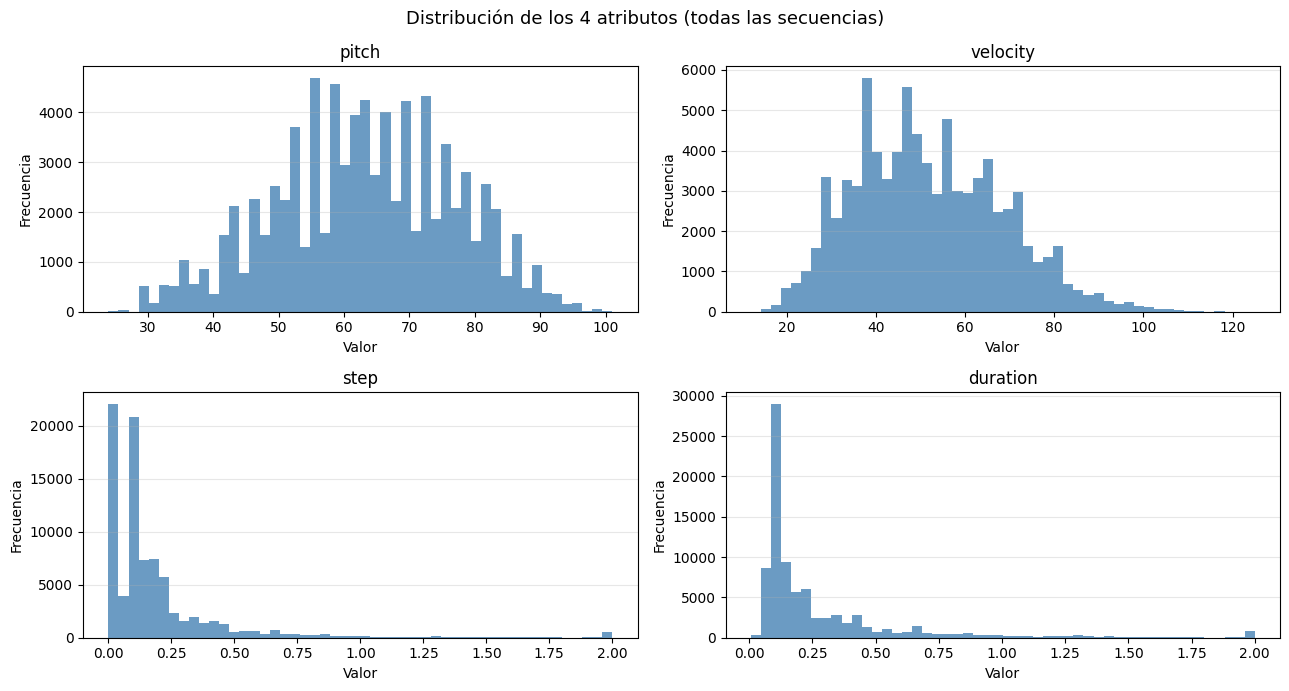

In [6]:
# --- 4.1 Instrumentos por archivo ---
name_counts = Counter(n.split(' — ')[0] for n in sequence_names)
print(f'{"Archivo":<45} Seqs')
print('-' * 52)
for fname, cnt in sorted(name_counts.items()):
    print(f'  {fname:<43} {cnt}')
print(f'\nTotal obras: {len(name_counts)}   Total secuencias: {len(sequences)}')

# --- 4.2 Notas por secuencia ---
notes_per = [len(s) for s in sequences]
print(f'\nNotas por secuencia: min={min(notes_per)}, max={max(notes_per)}, '
      f'media={np.mean(notes_per):.0f}, total={sum(notes_per):,}')

# --- 4.3 Distribuciones de los 4 atributos ---
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Distribución de los 4 atributos (todas las secuencias)', fontsize=13)
for ax, col, clip in [
    (axes[0, 0], 'pitch',    None),
    (axes[0, 1], 'velocity', None),
    (axes[1, 0], 'step',     2.0),
    (axes[1, 1], 'duration', 2.0),
]:
    vals = df_all[col].clip(0, clip) if clip else df_all[col]
    ax.hist(vals, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_title(col);  ax.set_xlabel('Valor');  ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Split por obra — sin fuga de información

El split se hace **agrupando por obra completa**, no por secuencias sueltas.
Si una obra tiene dos pistas de piano, ambas caen en el mismo split.

- **Test**: 3 obras fijas, nunca vistas durante entrenamiento ni validación.
- **Validation**: ≈10 % de las 26 obras restantes.
- **Train**: el resto.

La semilla `np.random.default_rng(42)` hace el split reproducible.


In [7]:
# Obras únicas (= nombre de archivo, sin el sufijo '— inst N')
unique_obras = sorted(set(n.split(' — ')[0] for n in sequence_names))
print(f'Obras únicas encontradas: {len(unique_obras)}')

rng       = np.random.default_rng(42)
shuffled  = rng.permutation(unique_obras).tolist()

test_obras  = shuffled[:3]                          # 3 obras para test
remaining   = shuffled[3:]                          # 26 obras
n_val       = max(1, round(len(remaining) * 0.10))  # ≈ 3 obras para val
val_obras   = remaining[:n_val]
train_obras = remaining[n_val:]

def get_split(obra_set):
    seqs  = [s for s, n in zip(sequences, sequence_names)
             if n.split(' — ')[0] in obra_set]
    names = [n for n in sequence_names
             if n.split(' — ')[0] in obra_set]
    return seqs, names

train_seqs, train_names = get_split(set(train_obras))
val_seqs,   val_names   = get_split(set(val_obras))
test_seqs,  test_names  = get_split(set(test_obras))

print(f'\n{"Split":<8} {"Obras":>5} {"Seqs":>5} {"Notas":>9}')
print('-' * 32)
for label, obra_list, seqs in [
    ('Train', train_obras, train_seqs),
    ('Val',   val_obras,   val_seqs),
    ('Test',  test_obras,  test_seqs),
]:
    total_n = sum(len(s) for s in seqs)
    print(f'{label:<8} {len(obra_list):>5} {len(seqs):>5} {total_n:>9,}')

print('\n--- Obras de TRAIN ---')
for o in sorted(train_obras): print(f'  {o}')
print('\n--- Obras de VAL ---')
for o in sorted(val_obras):   print(f'  {o}')
print('\n--- Obras de TEST (jamás vistas en entrenamiento) ---')
for o in sorted(test_obras):  print(f'  {o}')


Obras únicas encontradas: 23

Split    Obras  Seqs     Notas
--------------------------------
Train       18    37    65,228
Val          2     4    10,040
Test         3     6     9,517

--- Obras de TRAIN ---
  appass_1.mid
  appass_2.mid
  appass_3.mid
  beethoven_hammerklavier_1.mid
  beethoven_hammerklavier_2.mid
  beethoven_hammerklavier_3.mid
  beethoven_hammerklavier_4.mid
  beethoven_les_adieux_1.mid
  beethoven_les_adieux_2.mid
  beethoven_les_adieux_3.mid
  beethoven_opus10_2.mid
  beethoven_opus10_3.mid
  beethoven_opus22_1.mid
  beethoven_opus22_2.mid
  beethoven_opus22_3.mid
  elise.mid
  mond_1.mid
  mond_2.mid

--- Obras de VAL ---
  beethoven_opus22_4.mid
  mond_3.mid

--- Obras de TEST (jamás vistas en entrenamiento) ---
  beethoven_opus10_1.mid
  beethoven_opus90_1.mid
  beethoven_opus90_2.mid


## 6. Preprocesamiento discreto

Todo se ajusta **solo con datos de train** y luego se aplica a val y test:

| Atributo   | Tratamiento                                     | Bins |
|------------|--------------------------------------------------|------|
| pitch      | Reindexado 0..V-1 (vocab real) + UNK = V        | V+1  |
| velocity   | Bins por cuantiles (sin clipping)               | 8    |
| step       | Clip p99 → bins por cuantiles                   | 16   |
| duration   | Clip p99 → bins por cuantiles                   | 16   |

Se guardan los centros de bins para reconstruir valores reales en la generación.


In [8]:
# ── Clip outliers de step y duration (solo train) ────────────────────────
train_all     = pd.concat(train_seqs, ignore_index=True)
STEP_CLIP     = train_all['step'].quantile(0.99)
DURATION_CLIP = train_all['duration'].quantile(0.99)
print(f'Clip step     p99 (train): {STEP_CLIP:.4f} s')
print(f'Clip duration p99 (train): {DURATION_CLIP:.4f} s')

train_clipped = train_all.copy()
train_clipped['step']     = train_clipped['step'].clip(0, STEP_CLIP)
train_clipped['duration'] = train_clipped['duration'].clip(0, DURATION_CLIP)

# ── Bins por cuantiles (solo train) ──────────────────────────────────────
N_VEL_BINS  = 8
N_STEP_BINS = 16
N_DUR_BINS  = 16

def make_bins(values, n_bins):
    """Devuelve (edges[n_bins+1], centers[n_bins]) usando cuantiles uniformes."""
    edges = np.quantile(values, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9   # garantiza que el máximo caiga en el último bin
    centers = (edges[:-1] + edges[1:]) / 2
    return edges.astype(np.float64), centers.astype(np.float64)

vel_edges,  vel_centers  = make_bins(train_clipped['velocity'].values, N_VEL_BINS)
step_edges, step_centers = make_bins(train_clipped['step'].values,     N_STEP_BINS)
dur_edges,  dur_centers  = make_bins(train_clipped['duration'].values, N_DUR_BINS)

print(f'\nBins velocity  ({N_VEL_BINS}):  {vel_edges.round(1).tolist()}')
print(f'Centros: {vel_centers.round(1).tolist()}')
print(f'\nBins step      ({N_STEP_BINS}): {step_edges.round(4).tolist()}')
print(f'Centros: {step_centers.round(4).tolist()}')
print(f'\nBins duration  ({N_DUR_BINS}): {dur_edges.round(4).tolist()}')
print(f'Centros: {dur_centers.round(4).tolist()}')

# ── Vocabulario de pitch (solo train) ────────────────────────────────────
train_pitches    = sorted(int(p) for p in train_clipped['pitch'].unique())
pitch_to_idx     = {p: i for i, p in enumerate(train_pitches)}
UNK_PITCH_IDX    = len(train_pitches)          # índice reservado para pitches fuera del vocab
PITCH_VOCAB_SIZE = len(train_pitches) + 1      # V pitches conocidos + 1 UNK

# Mapeo inverso índice → pitch real (UNK → Do4 = 60 como fallback en generación)
idx_to_pitch = {i: p for p, i in pitch_to_idx.items()}
idx_to_pitch[UNK_PITCH_IDX] = 60

print(f'\nVocabulario de pitch (train): {len(train_pitches)} pitches + 1 UNK = {PITCH_VOCAB_SIZE} clases')
print(f'Rango: {min(train_pitches)}–{max(train_pitches)}')


Clip step     p99 (train): 1.7099 s
Clip duration p99 (train): 1.9873 s

Bins velocity  (8):  [12.0, 33.0, 39.0, 45.0, 51.0, 57.0, 64.0, 72.0, 125.0]
Centros: [22.5, 36.0, 42.0, 48.0, 54.0, 60.5, 68.0, 98.5]

Bins step      (16): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0762, 0.0909, 0.1018, 0.1079, 0.1196, 0.1382, 0.1717, 0.2158, 0.2679, 0.4018, 0.6316, 1.7099]
Centros: [0.0, 0.0, 0.0, 0.0, 0.0381, 0.0835, 0.0963, 0.1048, 0.1138, 0.1289, 0.155, 0.1938, 0.2418, 0.3348, 0.5167, 1.1708]

Bins duration  (16): [0.0068, 0.0734, 0.0877, 0.0915, 0.0987, 0.1056, 0.1132, 0.125, 0.1376, 0.1596, 0.2, 0.2457, 0.3206, 0.4167, 0.5634, 0.8673, 1.9873]
Centros: [0.0401, 0.0806, 0.0896, 0.0951, 0.1022, 0.1094, 0.1191, 0.1313, 0.1486, 0.1798, 0.2228, 0.2831, 0.3686, 0.49, 0.7154, 1.4273]

Vocabulario de pitch (train): 78 pitches + 1 UNK = 79 clases
Rango: 24–101


In [9]:
# ── Función de encoding ───────────────────────────────────────────────────
def encode_bins(values, edges, n_bins):
    """Convierte valores continuos a índices de bin 0..n_bins-1.
    Usa los n_bins-1 bordes interiores como delimitadores.
    """
    idx = np.digitize(values, edges[1:-1])   # devuelve 0..n_bins-1
    return np.clip(idx, 0, n_bins - 1).astype(np.int64)

def encode_sequence(seq_df):
    """Convierte un DataFrame de notas al array de índices enteros (N, 4).
    Columnas: [pitch_idx, vel_bin, step_bin, dur_bin]
    """
    arr = seq_df.copy()
    arr['step']     = arr['step'].clip(0, STEP_CLIP)
    arr['duration'] = arr['duration'].clip(0, DURATION_CLIP)

    pitch_idx = arr['pitch'].map(lambda p: pitch_to_idx.get(int(p), UNK_PITCH_IDX)).values.astype(np.int64)
    vel_bin   = encode_bins(arr['velocity'].values.astype(float), vel_edges,  N_VEL_BINS)
    step_bin  = encode_bins(arr['step'].values.astype(float),     step_edges, N_STEP_BINS)
    dur_bin   = encode_bins(arr['duration'].values.astype(float), dur_edges,  N_DUR_BINS)

    return np.stack([pitch_idx, vel_bin, step_bin, dur_bin], axis=1)  # (N, 4) int64

train_arrays = [encode_sequence(s) for s in train_seqs]
val_arrays   = [encode_sequence(s) for s in val_seqs]
test_arrays  = [encode_sequence(s) for s in test_seqs]

# ── Verificaciones ───────────────────────────────────────────────────────
print('=== Verificación del encoding ===')
print(f'Vocabulario de pitch : {PITCH_VOCAB_SIZE} clases '
      f'({len(train_pitches)} pitches reales + 1 UNK)')
print(f'Bins de velocity     : {N_VEL_BINS}')
print(f'Bins de step         : {N_STEP_BINS}')
print(f'Bins de duration     : {N_DUR_BINS}')

ex = train_arrays[0][5]
print(f'\nEjemplo (nota 6 de train_seqs[0]):')
print(f'  [pitch_idx={ex[0]}, vel_bin={ex[1]}, step_bin={ex[2]}, dur_bin={ex[3]}]')
print(f'  pitch real : {idx_to_pitch[ex[0]]}')
print(f'  vel_centro : {vel_centers[ex[1]]:.1f}')
print(f'  step_centro: {step_centers[ex[2]]:.4f} s')
print(f'  dur_centro : {dur_centers[ex[3]]:.4f} s')

# Proporción de UNK en val y test
for split_label, arrays in [('Val', val_arrays), ('Test', test_arrays)]:
    if not arrays:
        continue
    all_p    = np.concatenate([a[:, 0] for a in arrays])
    unk_n    = (all_p == UNK_PITCH_IDX).sum()
    pct      = 100 * unk_n / len(all_p)
    print(f'\n{split_label}: {unk_n} notas UNK de {len(all_p):,} ({pct:.2f}%)')


=== Verificación del encoding ===
Vocabulario de pitch : 79 clases (78 pitches reales + 1 UNK)
Bins de velocity     : 8
Bins de step         : 16
Bins de duration     : 16

Ejemplo (nota 6 de train_seqs[0]):
  [pitch_idx=41, vel_bin=1, step_bin=7, dur_bin=13]
  pitch real : 65
  vel_centro : 36.0
  step_centro: 0.1048 s
  dur_centro : 0.4900 s

Val: 0 notas UNK de 10,040 (0.00%)

Test: 0 notas UNK de 9,517 (0.00%)


## 7. Dataset y DataLoader


In [10]:
BLOCK_SIZE = 100   # notas de contexto
BATCH_SIZE = 64

class MusicDataLoader:
    """DataLoader de ventanas deslizantes sobre secuencias de enteros."""
    def __init__(self, sequences, block_size):
        self.block_size = block_size
        # Almacenar como tensores long (enteros)
        self.sequences  = [torch.tensor(s, dtype=torch.long) for s in sequences]

        self.indices = []
        for seq_idx, seq in enumerate(self.sequences):
            for start in range(len(seq) - block_size):
                self.indices.append((seq_idx, start))

        self.order    = np.random.permutation(len(self.indices))
        self.curr_pos = 0

    def get_batch(self, batch_size):
        batch_idx = self.order[self.curr_pos : self.curr_pos + batch_size]
        self.curr_pos += len(batch_idx)
        if len(batch_idx) < batch_size:
            self.curr_pos = 0
            self.order    = np.random.permutation(len(self.indices))
            if len(batch_idx) == 0:
                batch_idx     = self.order[:batch_size]
                self.curr_pos = batch_size
        xs, ys = [], []
        for i in batch_idx:
            seq_idx, start = self.indices[i]
            seq = self.sequences[seq_idx]
            xs.append(seq[start : start + self.block_size])
            ys.append(seq[start + self.block_size])
        return torch.stack(xs), torch.stack(ys)

    @property
    def n_examples(self):
        return len(self.indices)

train_loader = MusicDataLoader(train_arrays, BLOCK_SIZE)
val_loader   = MusicDataLoader(val_arrays,   BLOCK_SIZE)
test_loader  = MusicDataLoader(test_arrays,  BLOCK_SIZE)

print(f'Block size (contexto): {BLOCK_SIZE} notas')
print(f'Batch size:            {BATCH_SIZE}')
print(f'Ventanas de train:     {train_loader.n_examples:,}')
print(f'Ventanas de val:       {val_loader.n_examples:,}')
print(f'Ventanas de test:      {test_loader.n_examples:,}')

x_s, y_s = train_loader.get_batch(BATCH_SIZE)
print(f'\nForma de un lote:')
print(f'  x : {tuple(x_s.shape)}  → (batch, contexto, 4_atributos)  dtype={x_s.dtype}')
print(f'  y : {tuple(y_s.shape)}  → (batch, 4_atributos)             dtype={y_s.dtype}')
print()
# Rangos de x (contexto) y de y (targets) por atributo
header = f'  {"Atributo":<15} {"x min":>6} {"x max":>6}   {"y min":>6} {"y max":>6}'
print(header)
print('  ' + '-' * (len(header) - 2))
attrs = [('pitch_idx', 0, PITCH_VOCAB_SIZE - 1),
         ('vel_bin',   1, N_VEL_BINS  - 1),
         ('step_bin',  2, N_STEP_BINS - 1),
         ('dur_bin',   3, N_DUR_BINS  - 1)]
for name, col, v_max in attrs:
    x_min = x_s[:,:,col].min().item()
    x_max_v = x_s[:,:,col].max().item()
    y_min = y_s[:,col].min().item()
    y_max_v = y_s[:,col].max().item()
    ok = '✓' if x_max_v <= v_max and y_max_v <= v_max else '✗ FUERA DE RANGO'
    print(f'  {name:<15} {x_min:>6} {x_max_v:>6}   {y_min:>6} {y_max_v:>6}  {ok}')
print(f'\n  Vocab esperado: pitch 0-{PITCH_VOCAB_SIZE-1}, vel 0-{N_VEL_BINS-1}, '
      f'step 0-{N_STEP_BINS-1}, dur 0-{N_DUR_BINS-1}')


Block size (contexto): 100 notas
Batch size:            64
Ventanas de train:     61,528
Ventanas de val:       9,640
Ventanas de test:      8,917

Forma de un lote:
  x : (64, 100, 4)  → (batch, contexto, 4_atributos)  dtype=torch.int64
  y : (64, 4)  → (batch, 4_atributos)             dtype=torch.int64

  Atributo         x min  x max    y min  y max
  ---------------------------------------------
  pitch_idx            3     76       10     72  ✓
  vel_bin              0      7        0      7  ✓
  step_bin             4     15        4     15  ✓
  dur_bin              0     15        0     15  ✓

  Vocab esperado: pitch 0-78, vel 0-7, step 0-15, dur 0-15


## 8. Modelo LSTM con embeddings por atributo

```
Entrada (batch, T, 4) — 4 índices enteros por nota
  pitch_idx  → Embedding(PITCH_VOCAB_SIZE, 16)
  vel_bin    → Embedding(8, 4)
  step_bin   → Embedding(16, 8)
  dur_bin    → Embedding(16, 8)
  ─────────────────────────────
  Concatenado: (batch, T, 36)
       ↓
  LSTM(input=36, hidden=256, layers=3, dropout=0.4)
       ↓ último estado oculto
  Dropout(0.4)
       ↓
  head_pitch    → Linear(256, PITCH_VOCAB_SIZE)  [CrossEntropy × 2]
  head_velocity → Linear(256, 8)                [CrossEntropy × 1]
  head_step     → Linear(256, 16)               [CrossEntropy × 1]
  head_duration → Linear(256, 16)               [CrossEntropy × 1]
```


In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

# ── Hiperparámetros de arquitectura ──────────────────────────────────────
HIDDEN_SIZE  = 256
NUM_LAYERS   = 3
DROPOUT      = 0.4    # dropout entre capas LSTM
DROPOUT_OUT  = 0.4    # dropout antes de las cabezas

EMBED_PITCH = 16
EMBED_VEL   = 4
EMBED_STEP  = 8
EMBED_DUR   = 8
INPUT_DIM   = EMBED_PITCH + EMBED_VEL + EMBED_STEP + EMBED_DUR  # 36

class MusicLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        # Embeddings separados por atributo
        self.emb_pitch    = nn.Embedding(PITCH_VOCAB_SIZE, EMBED_PITCH)
        self.emb_velocity = nn.Embedding(N_VEL_BINS,       EMBED_VEL)
        self.emb_step     = nn.Embedding(N_STEP_BINS,      EMBED_STEP)
        self.emb_duration = nn.Embedding(N_DUR_BINS,       EMBED_DUR)

        # LSTM de 3 capas con dropout entre ellas
        self.lstm = nn.LSTM(
            input_size  = INPUT_DIM,
            hidden_size = HIDDEN_SIZE,
            num_layers  = NUM_LAYERS,
            batch_first = True,
            dropout     = DROPOUT,
        )
        self.dropout_out = nn.Dropout(DROPOUT_OUT)

        # Cuatro cabezas de clasificación (todas CrossEntropy)
        self.head_pitch    = nn.Linear(HIDDEN_SIZE, PITCH_VOCAB_SIZE)
        self.head_velocity = nn.Linear(HIDDEN_SIZE, N_VEL_BINS)
        self.head_step     = nn.Linear(HIDDEN_SIZE, N_STEP_BINS)
        self.head_duration = nn.Linear(HIDDEN_SIZE, N_DUR_BINS)

    def forward(self, x):
        # x : (batch, T, 4)  dtype=long
        # Columnas: [pitch_idx, vel_bin, step_bin, dur_bin]
        p_emb = self.emb_pitch(x[:, :, 0])     # (batch, T, 16)
        v_emb = self.emb_velocity(x[:, :, 1])  # (batch, T,  4)
        s_emb = self.emb_step(x[:, :, 2])      # (batch, T,  8)
        d_emb = self.emb_duration(x[:, :, 3])  # (batch, T,  8)

        lstm_in  = torch.cat([p_emb, v_emb, s_emb, d_emb], dim=-1)  # (batch, T, 36)
        lstm_out, _ = self.lstm(lstm_in)                             # (batch, T, 256)
        last     = self.dropout_out(lstm_out[:, -1, :])             # (batch, 256)

        return (
            self.head_pitch(last),     # (batch, PITCH_VOCAB_SIZE)
            self.head_velocity(last),  # (batch, N_VEL_BINS)
            self.head_step(last),      # (batch, N_STEP_BINS)
            self.head_duration(last),  # (batch, N_DUR_BINS)
        )

model = MusicLSTM().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parámetros totales: {n_params:,}')
print(f'\nDimensiones de entrada al LSTM:')
print(f'  emb_pitch    : Embedding({PITCH_VOCAB_SIZE}, {EMBED_PITCH})')
print(f'  emb_velocity : Embedding({N_VEL_BINS}, {EMBED_VEL})')
print(f'  emb_step     : Embedding({N_STEP_BINS}, {EMBED_STEP})')
print(f'  emb_duration : Embedding({N_DUR_BINS}, {EMBED_DUR})')
print(f'  → Concatenado : {INPUT_DIM}D por nota  (dimensión final de entrada al LSTM)')
print(f'\nLSTM : input={INPUT_DIM}, hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, dropout={DROPOUT}')
print(model)


Dispositivo: cuda
Parámetros totales: 1,385,863

Dimensiones de entrada al LSTM:
  emb_pitch    : Embedding(79, 16)
  emb_velocity : Embedding(8, 4)
  emb_step     : Embedding(16, 8)
  emb_duration : Embedding(16, 8)
  → Concatenado : 36D por nota  (dimensión final de entrada al LSTM)

LSTM : input=36, hidden=256, layers=3, dropout=0.4
MusicLSTM(
  (emb_pitch): Embedding(79, 16)
  (emb_velocity): Embedding(8, 4)
  (emb_step): Embedding(16, 8)
  (emb_duration): Embedding(16, 8)
  (lstm): LSTM(36, 256, num_layers=3, batch_first=True, dropout=0.4)
  (dropout_out): Dropout(p=0.4, inplace=False)
  (head_pitch): Linear(in_features=256, out_features=79, bias=True)
  (head_velocity): Linear(in_features=256, out_features=8, bias=True)
  (head_step): Linear(in_features=256, out_features=16, bias=True)
  (head_duration): Linear(in_features=256, out_features=16, bias=True)
)


## 9. Entrenamiento

**Función de pérdida total:**
$$\mathcal{L} = 2\,CE_{pitch} + CE_{velocity} + CE_{step} + CE_{duration}$$

**Early stopping** basado exclusivamente en `val total_loss`.  
**Test** se evalúa **una sola vez** al final, con el mejor checkpoint.


In [12]:
ce_loss = nn.CrossEntropyLoss()

def composed_loss(pitch_logits, vel_logits, step_logits, dur_logits, y):
    """
    y : (batch, 4) dtype=long  [pitch_idx, vel_bin, step_bin, dur_bin]
    Devuelve (total, l_pitch, l_velocity, l_step, l_duration)
    total = 2*pitch_CE + vel_CE + step_CE + dur_CE
    """
    l_pitch    = ce_loss(pitch_logits, y[:, 0])
    l_velocity = ce_loss(vel_logits,   y[:, 1])
    l_step     = ce_loss(step_logits,  y[:, 2])
    l_duration = ce_loss(dur_logits,   y[:, 3])
    total = 2 * l_pitch + l_velocity + l_step + l_duration
    return total, l_pitch, l_velocity, l_step, l_duration

def compute_accuracy(logits, targets):
    return (logits.argmax(dim=-1) == targets).float().mean().item()

@torch.no_grad()
def estimate_metrics(model, loader, n_batches=30):
    """Estima métricas sobre n_batches aleatorios del loader."""
    model.eval()
    acc = defaultdict(float)
    for _ in range(n_batches):
        x, y = loader.get_batch(BATCH_SIZE)
        x, y = x.to(device), y.to(device)
        pl, vl, sl, dl = model(x)
        total, lp, lv, ls, ld = composed_loss(pl, vl, sl, dl, y)
        acc['total']     += total.item()
        acc['pitch']     += lp.item()
        acc['velocity']  += lv.item()
        acc['step']      += ls.item()
        acc['duration']  += ld.item()
        acc['pitch_acc'] += compute_accuracy(pl, y[:, 0])
        acc['vel_acc']   += compute_accuracy(vl, y[:, 1])
        acc['step_acc']  += compute_accuracy(sl, y[:, 2])
        acc['dur_acc']   += compute_accuracy(dl, y[:, 3])
    model.train()
    return {k: v / n_batches for k, v in acc.items()}

@torch.no_grad()
def evaluate_full(model, loader):
    """Evaluación exhaustiva sobre todas las ventanas del loader (sin muestreo)."""
    model.eval()
    totals = defaultdict(float)
    n = 0
    for start in range(0, len(loader.indices), BATCH_SIZE):
        idx_batch = loader.indices[start : start + BATCH_SIZE]
        if not idx_batch:
            break
        xs, ys = [], []
        for seq_idx, s in idx_batch:
            seq = loader.sequences[seq_idx]
            xs.append(seq[s : s + loader.block_size])
            ys.append(seq[s + loader.block_size])
        x = torch.stack(xs).to(device)
        y = torch.stack(ys).to(device)
        pl, vl, sl, dl = model(x)
        total, lp, lv, ls, ld = composed_loss(pl, vl, sl, dl, y)
        b = len(idx_batch)
        totals['total']     += total.item() * b
        totals['pitch']     += lp.item()    * b
        totals['velocity']  += lv.item()    * b
        totals['step']      += ls.item()    * b
        totals['duration']  += ld.item()    * b
        totals['pitch_acc'] += compute_accuracy(pl, y[:, 0]) * b
        totals['vel_acc']   += compute_accuracy(vl, y[:, 1]) * b
        totals['step_acc']  += compute_accuracy(sl, y[:, 2]) * b
        totals['dur_acc']   += compute_accuracy(dl, y[:, 3]) * b
        n += b
    model.train()
    return {k: v / n for k, v in totals.items()}


In [13]:
LR           = 0.0003
WEIGHT_DECAY = 0.0001
EPOCHS       = 10
ES_PATIENCE  = 5      # épocas sin mejora antes de parar
ES_MIN_DELTA = 0.001  # mejora mínima que cuenta como progreso

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

best_val_loss    = float('inf')
es_counter       = 0
best_model_state = None

log = {split: defaultdict(list) for split in ['train', 'val']}

steps_per_epoch = train_loader.n_examples // BATCH_SIZE
print(f'Pasos por época : {steps_per_epoch}')
print(f'Épocas máximas  : {EPOCHS}')
print(f'Early stopping  : paciencia = {ES_PATIENCE} épocas')
print(f'Grad clipping   : max_norm=1.0\n')

for epoch in range(1, EPOCHS + 1):
    model.train()

    # ── Entrenamiento de una época ────────────────────────────────────────
    for _ in range(steps_per_epoch):
        x, y = train_loader.get_batch(BATCH_SIZE)
        x, y = x.to(device), y.to(device)
        loss, *_ = composed_loss(*model(x), y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # estabilidad LSTM
        optimizer.step()

    # ── Evaluación al final de la época ─────────────────────────────────
    train_m = estimate_metrics(model, train_loader, n_batches=30)
    val_m   = estimate_metrics(model, val_loader,   n_batches=30)

    for split, m in [('train', train_m), ('val', val_m)]:
        for k, v in m.items():
            log[split][k].append(v)

    # ── Scheduler y early stopping sobre val loss ────────────────────────
    scheduler.step(val_m['total'])
    val_loss = val_m['total']
    if val_loss < best_val_loss - ES_MIN_DELTA:
        best_val_loss    = val_loss
        es_counter       = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        es_counter += 1

    # ── Logging estructurado ─────────────────────────────────────────────
    lr_curr = optimizer.param_groups[0]['lr']
    sep  = '  ' + '-' * 66
    hdr  = f'  {"":12}  {"pitch":>7}  {"vel":>7}  {"step":>7}  {"dur":>7}  {"total":>7}'

    print(f'Época {epoch:2d}/{EPOCHS}  '
          f'[ES {es_counter}/{ES_PATIENCE}]  LR={lr_curr:.2e}')
    print(hdr)
    print(sep)
    for tag, m in [('Train loss', train_m), ('Val   loss', val_m)]:
        print(f'  {tag:<12}  '
              f'{m["pitch"]:>7.3f}  '
              f'{m["velocity"]:>7.3f}  '
              f'{m["step"]:>7.3f}  '
              f'{m["duration"]:>7.3f}  '
              f'{m["total"]:>7.3f}')
    print(sep)
    for tag, m in [('Train pp  ', train_m), ('Val   pp  ', val_m)]:
        print(f'  {tag:<12}  '
              f'{np.exp(m["pitch"]):>7.1f}  '
              f'{np.exp(m["velocity"]):>7.1f}  '
              f'{np.exp(m["step"]):>7.1f}  '
              f'{np.exp(m["duration"]):>7.1f}')
    print(sep)
    for tag, m in [('Train acc ', train_m), ('Val   acc ', val_m)]:
        print(f'  {tag:<12}  '
              f'{m["pitch_acc"]:>7.3f}  '
              f'{m["vel_acc"]:>7.3f}  '
              f'{m["step_acc"]:>7.3f}  '
              f'{m["dur_acc"]:>7.3f}')
    print()

    if es_counter >= ES_PATIENCE:
        print(f'Early stopping en época {epoch}. Mejor val loss: {best_val_loss:.4f}')
        break

# Restaurar el mejor modelo según val loss
if best_model_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    print(f'Modelo restaurado al mejor checkpoint (val_loss = {best_val_loss:.4f})')
else:
    print('No se guardó checkpoint (entrenamiento muy corto).')


Pasos por época : 961
Épocas máximas  : 10
Early stopping  : paciencia = 5 épocas
Grad clipping   : max_norm=1.0

Época  1/10  [ES 0/5]  LR=3.00e-04
                  pitch      vel     step      dur    total
  ------------------------------------------------------------------
  Train loss      3.176    1.481    1.222    1.368   10.423
  Val   loss      3.486    1.735    1.334    1.839   11.881
  ------------------------------------------------------------------
  Train pp         23.9      4.4      3.4      3.9
  Val   pp         32.7      5.7      3.8      6.3
  ------------------------------------------------------------------
  Train acc       0.130    0.420    0.590    0.584
  Val   acc       0.076    0.310    0.554    0.465

Época  2/10  [ES 0/5]  LR=3.00e-04
                  pitch      vel     step      dur    total
  ------------------------------------------------------------------
  Train loss      2.886    1.291    1.113    1.212    9.389
  Val   loss      3.172    1.549   

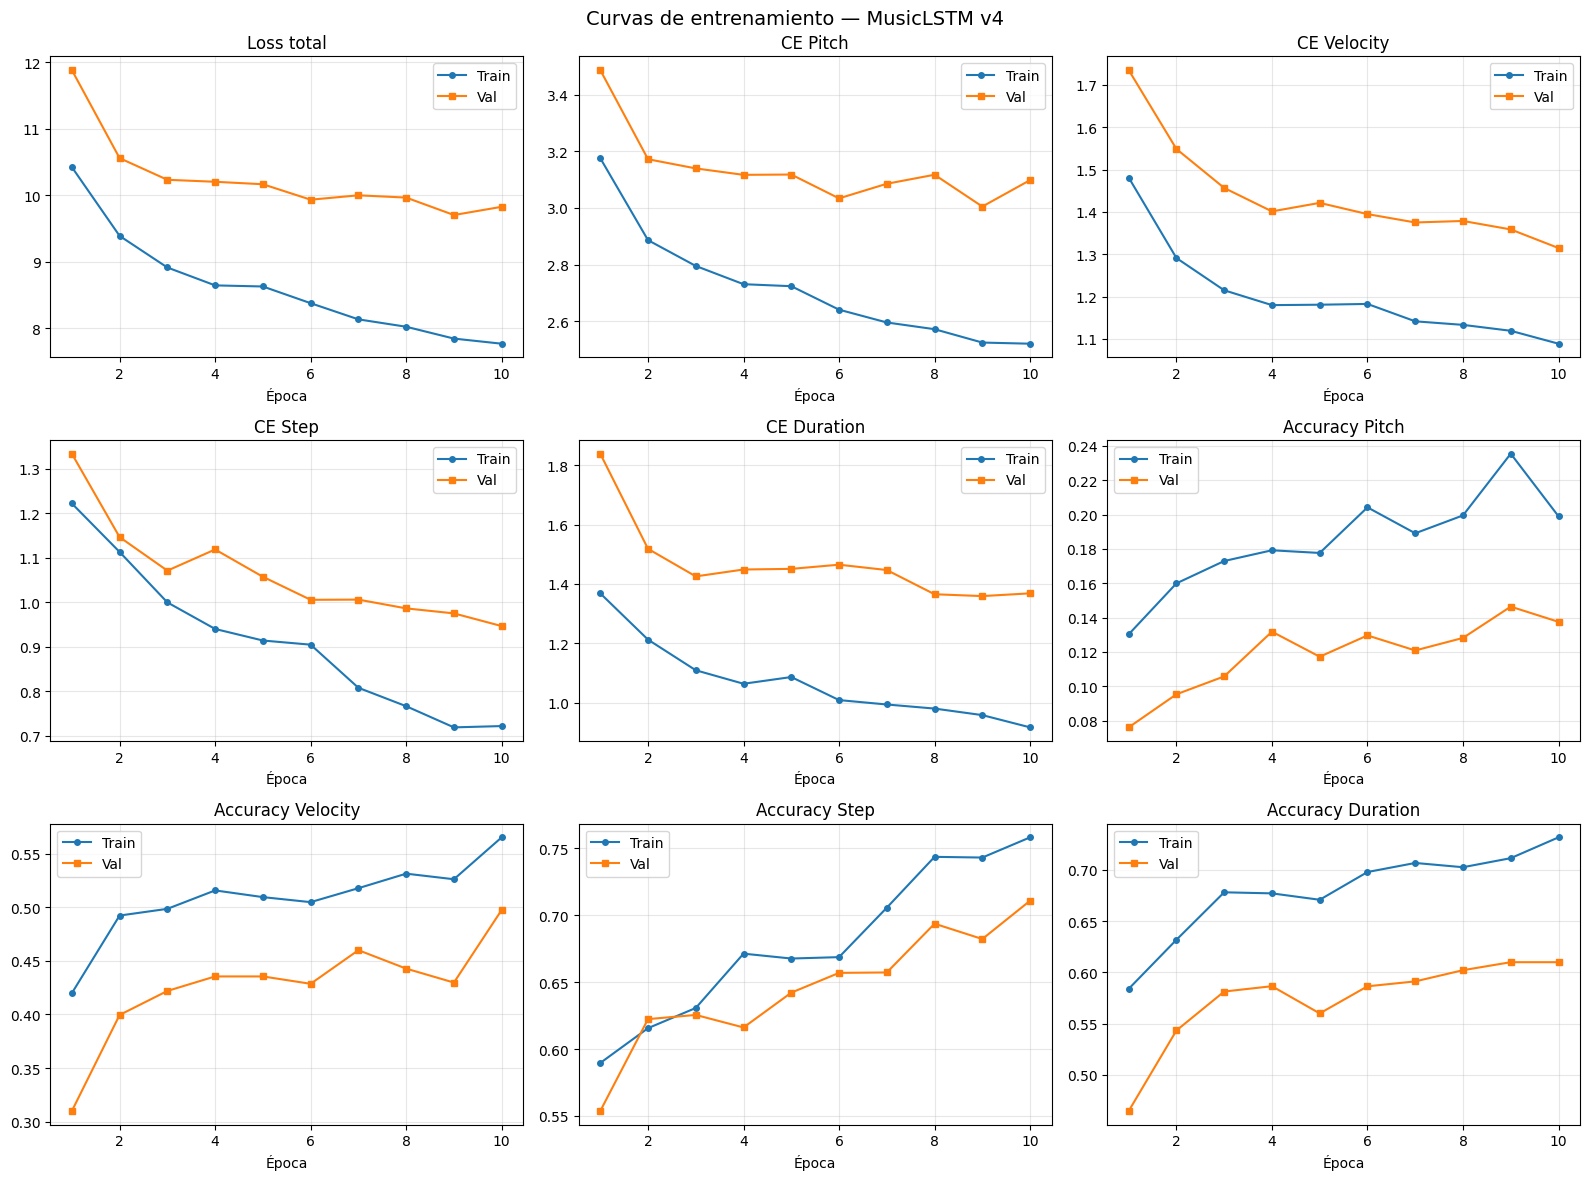


Resumen última época registrada:
Métrica            Train      Val
-----------------------------------
total             7.7691   9.8257
pitch             2.5208   3.0980
velocity          1.0887   1.3146
step              0.7222   0.9467
duration          0.9165   1.3683
pitch_acc         0.1990   0.1375
vel_acc           0.5651   0.4974
step_acc          0.7583   0.7109
dur_acc           0.7318   0.6099


In [14]:
# --- Curvas de entrenamiento (losses + accuracies) ---
epochs_logged = list(range(1, len(log['train']['total']) + 1))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Curvas de entrenamiento — MusicLSTM v4', fontsize=14)

metrics_to_plot = [
    ('total',     'Loss total',       axes[0, 0]),
    ('pitch',     'CE Pitch',         axes[0, 1]),
    ('velocity',  'CE Velocity',      axes[0, 2]),
    ('step',      'CE Step',          axes[1, 0]),
    ('duration',  'CE Duration',      axes[1, 1]),
    ('pitch_acc', 'Accuracy Pitch',   axes[1, 2]),
    ('vel_acc',   'Accuracy Velocity',axes[2, 0]),
    ('step_acc',  'Accuracy Step',    axes[2, 1]),
    ('dur_acc',   'Accuracy Duration',axes[2, 2]),
]

for key, title, ax in metrics_to_plot:
    ax.plot(epochs_logged, log['train'][key], label='Train', marker='o', ms=4)
    ax.plot(epochs_logged, log['val'][key],   label='Val',   marker='s', ms=4)
    ax.set_title(title); ax.set_xlabel('Época'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Tabla resumen de la última época
print('\nResumen última época registrada:')
print(f'{"Métrica":<15} {"Train":>8} {"Val":>8}')
print('-' * 35)
for key in ['total','pitch','velocity','step','duration',
            'pitch_acc','vel_acc','step_acc','dur_acc']:
    t = log['train'][key][-1] if log['train'][key] else float('nan')
    v = log['val'][key][-1]   if log['val'][key]   else float('nan')
    print(f'{key:<15} {t:8.4f} {v:8.4f}')


## 10. Evaluación final en Test

Se evalúa **una sola vez** sobre todas las ventanas del set de test,
usando el mejor checkpoint según validation loss.


In [15]:
test_m = evaluate_full(model, test_loader)

print('=== Evaluación final en TEST (mejor modelo) ===')
print()
print(f'{"Métrica":<15} {"Valor":>10}')
print('-' * 28)
for k, v in test_m.items():
    print(f'{k:<15} {v:10.4f}')

print('\nPerplexity individual (exp de cada loss CE):')
for k in ['pitch', 'velocity', 'step', 'duration']:
    pp_val = np.exp(test_m[k])
    print(f'  {k:<12}  loss={test_m[k]:.4f}  perplexity={pp_val:.2f}')


=== Evaluación final en TEST (mejor modelo) ===

Métrica              Valor
----------------------------
total               9.6826
pitch               3.0372
velocity            1.4381
step                0.9640
duration            1.2061
pitch_acc           0.1356
vel_acc             0.4207
step_acc            0.6622
dur_acc             0.6803

Perplexity individual (exp de cada loss CE):
  pitch         loss=3.0372  perplexity=20.85
  velocity      loss=1.4381  perplexity=4.21
  step          loss=0.9640  perplexity=2.62
  duration      loss=1.2061  perplexity=3.34


## 11. Generación MIDI

Dos modos de generación:
- **`temperature=None`** → argmax en cada cabeza (determinista, reproducible)
- **`temperature=float`** → softmax(logits/T) + muestreo multinomial
  - T < 1: más conservador  · T > 1: más variado

La reconstrucción de valores reales usa los **centros de bins**:
velocity → `vel_centers[vel_bin]`, step → `step_centers[step_bin]`, etc.


In [16]:
@torch.no_grad()
def generate_notes(model, seed_array, n_notes=200, temperature=None):
    """
    Genera n_notes notas a partir de un seed de enteros codificados.

    temperature=None  → argmax en todas las salidas (determinista)
    temperature=float → sampling con temperatura solo en pitch;
                        vel, step y duration usan siempre argmax.

    El token UNK de pitch nunca se selecciona: se enmascara antes de
    argmax/sampling poniendo su logit a -inf.

    Devuelve un DataFrame con columnas [pitch, step, duration, velocity]
    en valores reales (centros de bins).
    """
    model.eval()
    context = torch.tensor(
        seed_array[-BLOCK_SIZE:], dtype=torch.long
    ).unsqueeze(0).to(device)   # (1, BLOCK_SIZE, 4)

    generated = []
    for _ in range(n_notes):
        pitch_logits, vel_logits, step_logits, dur_logits = model(context)

        # ── Pitch: enmascarar UNK antes de seleccionar ───────────────────
        p_logits = pitch_logits[0].clone()
        p_logits[UNK_PITCH_IDX] = float('-inf')   # UNK nunca se genera

        if temperature is None:
            # Modo determinista: argmax en todas las cabezas
            pitch_idx = p_logits.argmax().item()
        else:
            # Sampling con temperatura solo en pitch
            probs     = torch.softmax(p_logits / temperature, dim=-1)
            pitch_idx = torch.multinomial(probs, num_samples=1).item()

        # vel, step, dur: siempre argmax (independiente de temperature)
        vel_bin  = vel_logits[0].argmax().item()
        step_bin = step_logits[0].argmax().item()
        dur_bin  = dur_logits[0].argmax().item()

        generated.append([pitch_idx, vel_bin, step_bin, dur_bin])

        # Deslizar ventana de contexto
        new_note = torch.tensor(
            [[pitch_idx, vel_bin, step_bin, dur_bin]], dtype=torch.long
        ).unsqueeze(0).to(device)
        context = torch.cat([context[:, 1:, :], new_note], dim=1)

    # Reconstruir valores reales usando centros de bins
    rows = []
    for pitch_idx, vel_bin, step_bin, dur_bin in generated:
        # pitch_idx está garantizado en el rango del vocab real (sin UNK)
        pitch    = idx_to_pitch[pitch_idx]
        velocity = int(np.clip(vel_centers[vel_bin],  1,    127))
        step     = float(np.clip(step_centers[step_bin], 0,  None))
        duration = float(np.clip(dur_centers[dur_bin],  0.01, None))
        rows.append({'pitch': pitch, 'step': step,
                     'duration': duration, 'velocity': velocity})

    return pd.DataFrame(rows).astype({'pitch': int, 'velocity': int})


In [17]:
if COLAB:
    GENERATED_DIR = '/content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated'
else:
    GENERATED_DIR = '../generated'

os.makedirs(GENERATED_DIR, exist_ok=True)

def notes_to_midi(df_notes, output_path, instrument_name='Acoustic Grand Piano'):
    pm_out   = pretty_midi.PrettyMIDI()
    program  = pretty_midi.instrument_name_to_program(instrument_name)
    inst_out = pretty_midi.Instrument(program=program)
    current_start = 0.0
    for _, row in df_notes.iterrows():
        current_start += float(row['step'])
        note = pretty_midi.Note(
            velocity = int(np.clip(row['velocity'], 1, 127)),
            pitch    = int(np.clip(row['pitch'],    0, 127)),
            start    = current_start,
            end      = current_start + float(row['duration']),
        )
        inst_out.notes.append(note)
    pm_out.instruments.append(inst_out)
    pm_out.write(output_path)

def decode_seed(seed_array):
    """Convierte un seed de índices enteros a DataFrame con valores reales."""
    rows = []
    for row in seed_array:
        pitch_idx, vel_bin, step_bin, dur_bin = int(row[0]), int(row[1]), int(row[2]), int(row[3])
        rows.append({
            'pitch':    idx_to_pitch.get(pitch_idx, 60),
            'velocity': int(np.clip(vel_centers[vel_bin],  1,    127)),
            'step':     float(np.clip(step_centers[step_bin], 0, None)),
            'duration': float(np.clip(dur_centers[dur_bin],  0.01, None)),
        })
    return pd.DataFrame(rows).astype({'pitch': int, 'velocity': int})

# ── Generar tres versiones: argmax y dos temperaturas ───────────────────
configs = [
    ('argmax',   None),   # determinista
    ('temp_0.7', 0.7),    # conservador
    ('temp_1.0', 1.0),    # balanceado
]

seed_raw = test_arrays[0][:BLOCK_SIZE]
df_seed  = decode_seed(seed_raw)

for tag, temp in configs:
    df_gen  = generate_notes(model, seed_raw, n_notes=200, temperature=temp)
    df_full = pd.concat([df_seed, df_gen], ignore_index=True)
    fpath   = os.path.join(GENERATED_DIR, f'beethoven_1_4_{tag}.mid')
    notes_to_midi(df_full, fpath)
    mode = 'argmax (determinista)' if temp is None else f'temperatura={temp}'
    print(f'Guardado: beethoven_1_4_{tag}.mid  '
          f'({len(df_seed)} seed + {len(df_gen)} generadas)  [{mode}]')

print(f'\nMIDIs generados en: {GENERATED_DIR}')

if COLAB:
    from google.colab import files
    for tag, _ in configs:
        fpath = os.path.join(GENERATED_DIR, f'beethoven_1_4_{tag}.mid')
        files.download(fpath)
        print(f'Descargando: beethoven_1_4_{tag}.mid')


Guardado: beethoven_1_4_argmax.mid  (100 seed + 200 generadas)  [argmax (determinista)]
Guardado: beethoven_1_4_temp_0.7.mid  (100 seed + 200 generadas)  [temperatura=0.7]
Guardado: beethoven_1_4_temp_1.0.mid  (100 seed + 200 generadas)  [temperatura=1.0]

MIDIs generados en: /content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_1_4_argmax.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_1_4_temp_0.7.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_1_4_temp_1.0.mid


## 12. Evaluación: generado vs real


In [23]:
# --- 12.1 Cargar el MIDI generado (argmax) y la continuación real ---
pm_gen = pretty_midi.PrettyMIDI(os.path.join(GENERATED_DIR, 'beethoven_1_4_temp_0.7.mid'))
notes_gen_raw = sorted(pm_gen.instruments[0].notes, key=lambda n: n.start)

rows_gen, prev_start = [], None
for n in notes_gen_raw:
    step = n.start - prev_start if prev_start is not None else 0.0
    rows_gen.append({'pitch': n.pitch, 'step': step,
                     'duration': n.end - n.start, 'velocity': n.velocity})
    prev_start = n.start
df_gen_eval = pd.DataFrame(rows_gen)

# Secuencia real de referencia (test_seqs[0])
seq_real       = test_seqs[0].reset_index(drop=True)
df_real_seed   = seq_real.iloc[:BLOCK_SIZE]
df_real_next   = seq_real.iloc[BLOCK_SIZE : BLOCK_SIZE + 200].reset_index(drop=True)

# Solo notas generadas (sin seed)
df_gen_only = df_gen_eval.iloc[BLOCK_SIZE:].reset_index(drop=True)

print(f'Notas de contexto (seed):         {len(df_real_seed)}')
print(f'Notas reales de continuación:     {len(df_real_next)}')
print(f'Notas generadas (sin seed):       {len(df_gen_only)}')

stats = pd.DataFrame({
    'pitch_mean':    [df_gen_only['pitch'].mean(),    df_real_next['pitch'].mean()],
    'pitch_std':     [df_gen_only['pitch'].std(),     df_real_next['pitch'].std()],
    'step_mean':     [df_gen_only['step'].mean(),     df_real_next['step'].mean()],
    'step_std':      [df_gen_only['step'].std(),      df_real_next['step'].std()],
    'duration_mean': [df_gen_only['duration'].mean(), df_real_next['duration'].mean()],
    'velocity_mean': [df_gen_only['velocity'].mean(), df_real_next['velocity'].mean()],
}, index=['Generado', 'Real (ref)']).T.round(4)
print('\nComparación estadística:')
print(stats)


Notas de contexto (seed):         100
Notas reales de continuación:     200
Notas generadas (sin seed):       200

Comparación estadística:
               Generado  Real (ref)
pitch_mean      70.2650     69.5000
pitch_std       11.9397      8.2960
step_mean        0.0843      0.3069
step_std         0.0112      0.3312
duration_mean    0.0805      0.3021
velocity_mean   98.0000     61.9950


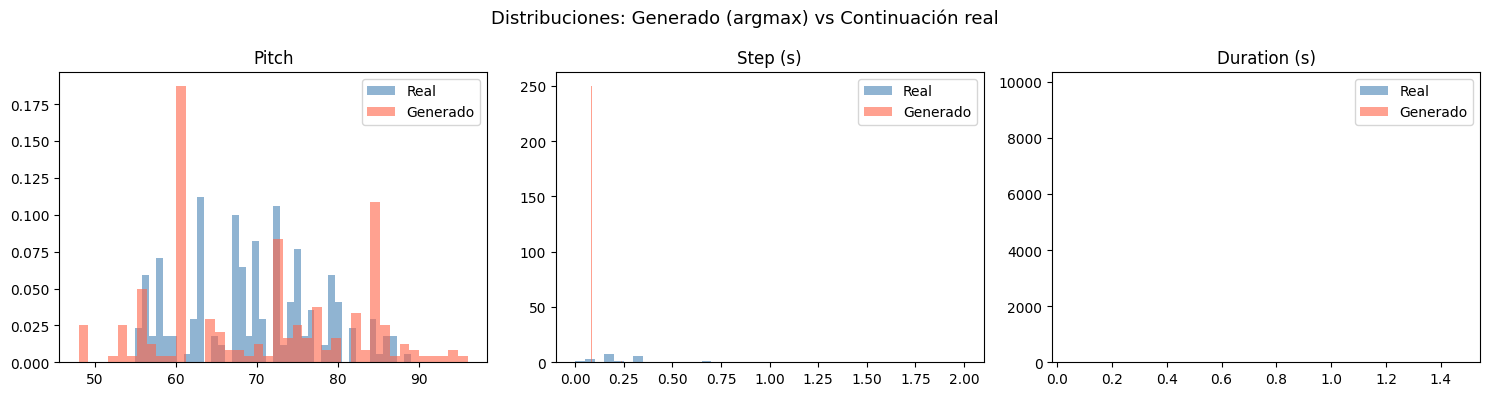

In [24]:
# --- 12.2 Distribuciones comparadas ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribuciones: Generado (argmax) vs Continuación real', fontsize=13)

for ax, col, label, clip_val in [
    (axes[0], 'pitch',    'Pitch',        None),
    (axes[1], 'step',     'Step (s)',      2.0),
    (axes[2], 'duration', 'Duration (s)', 2.0),
]:
    gen_vals  = df_gen_only[col].clip(0, clip_val)  if clip_val else df_gen_only[col]
    real_vals = df_real_next[col].clip(0, clip_val) if clip_val else df_real_next[col]
    ax.hist(real_vals, bins=40, alpha=0.6, label='Real',     density=True, color='steelblue')
    ax.hist(gen_vals,  bins=40, alpha=0.6, label='Generado', density=True, color='tomato')
    ax.set_title(label); ax.legend()

plt.tight_layout(); plt.show()


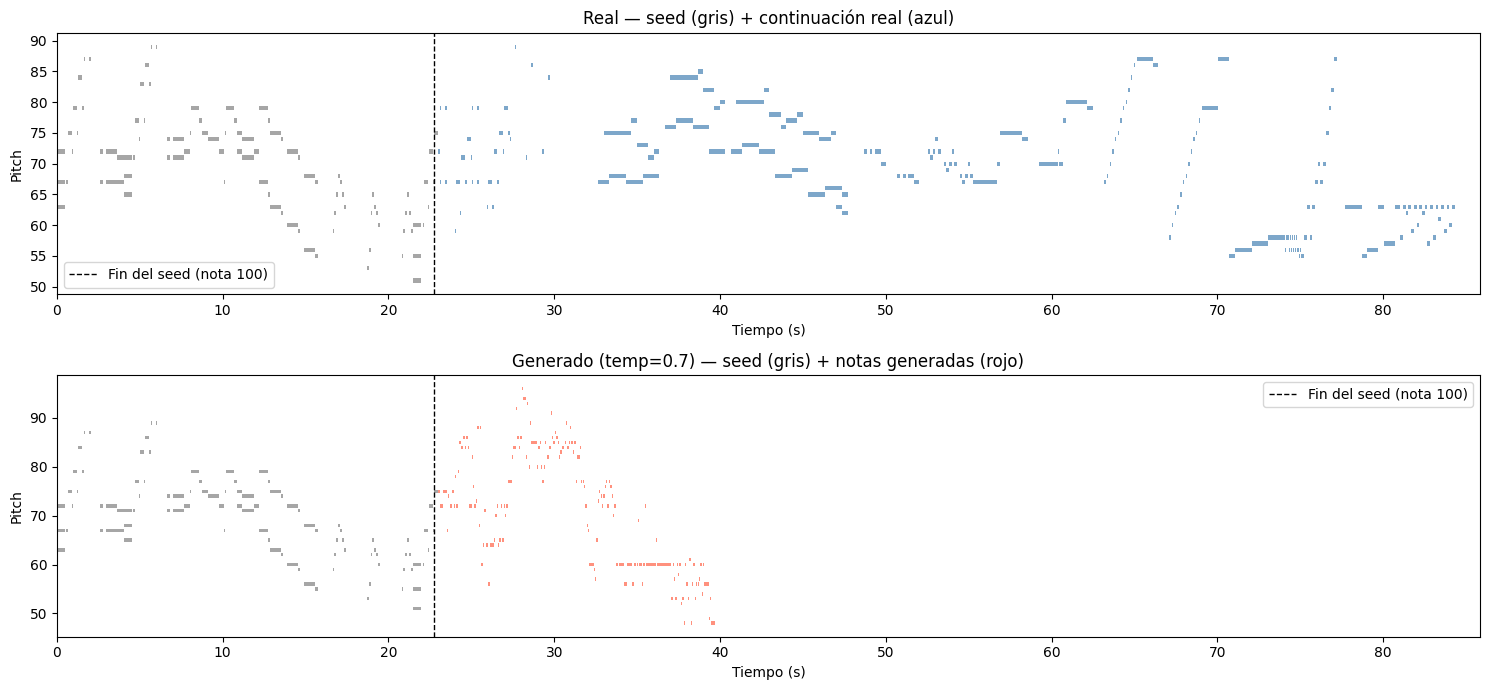

Step promedio real:     0.3069 s
Step promedio generado: 0.0843 s
Ratio gen/real:         0.27x  ← más rápido


In [26]:
# --- 12.3 Piano roll: seed + generado vs seed + continuación real ---
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

def plot_roll(ax, df, color, offset_t=0.0):
    t = offset_t
    for _, row in df.iterrows():
        t += row['step']
        ax.barh(row['pitch'], row['duration'], left=t, height=0.7,
                color=color, alpha=0.7)
    return t

seed_end = float(df_real_seed['step'].sum())
t_real   = seed_end + float(df_real_next['step'].sum())
t_gen    = seed_end + float(df_gen_only['step'].sum())
x_max    = max(t_real, t_gen) * 1.02

plot_roll(axes[0], df_real_seed, 'gray')
plot_roll(axes[0], df_real_next, 'steelblue', offset_t=seed_end)
axes[0].axvline(seed_end, color='black', linestyle='--', lw=1,
                label=f'Fin del seed (nota {BLOCK_SIZE})')
axes[0].set_title(f'Real — seed (gris) + continuación real (azul)')
axes[0].set_xlabel('Tiempo (s)'); axes[0].set_ylabel('Pitch')
axes[0].set_xlim(0, x_max); axes[0].legend()

plot_roll(axes[1], df_real_seed, 'gray')
plot_roll(axes[1], df_gen_only,  'tomato', offset_t=seed_end)
axes[1].axvline(seed_end, color='black', linestyle='--', lw=1,
                label=f'Fin del seed (nota {BLOCK_SIZE})')
axes[1].set_title('Generado (temp=0.7) — seed (gris) + notas generadas (rojo)')
axes[1].set_xlabel('Tiempo (s)'); axes[1].set_ylabel('Pitch')
axes[1].set_xlim(0, x_max); axes[1].legend()

plt.tight_layout(); plt.show()

ratio = (df_gen_only['step'].mean() / df_real_next['step'].mean()
         if df_real_next['step'].mean() > 0 else float('inf'))
print(f'Step promedio real:     {df_real_next["step"].mean():.4f} s')
print(f'Step promedio generado: {df_gen_only["step"].mean():.4f} s')
print(f'Ratio gen/real:         {ratio:.2f}x  '
      f'{"← más rápido" if ratio < 1 else "← más lento" if ratio > 1 else "← igual"}')


## 14. Generación con Top-K Sampling

En lugar de temperatura usamos **Top-K Sampling**:

1. Se conservan únicamente los **K logits más altos** de pitch; el resto se lleva a `-inf`.
2. Se aplica softmax y se muestrea con `torch.multinomial`.

Valores pequeños de K (p. ej. K = 5) producen música más conservadora;  
valores grandes (K = 50) permiten mayor variedad pero pueden introducir más saltos.  
El token UNK de pitch sigue enmascarado antes de aplicar top-K.  
`vel`, `step` y `duration` se seleccionan siempre por argmax.

In [33]:
def sample_from_logits(logits, temperature=1.0, top_k=None):
    if temperature is None:
        return logits.argmax().item()

    logits = logits / temperature

    if top_k is not None:
        values, indices = torch.topk(logits, top_k)
        probs = torch.softmax(values, dim=-1)
        idx = torch.multinomial(probs, 1).item()
        return indices[idx].item()
    else:
        probs = torch.softmax(logits, dim=-1)
        return torch.multinomial(probs, 1).item()

In [34]:
@torch.no_grad()
def generate_notes_topk(model, seed_array, n_notes=200, k=10):
    """
    Genera n_notes notas usando Top-K Sampling en la cabeza de pitch.

    k=1  equivale a argmax (determinista).
    Valores más altos de k introducen mayor variedad.

    El token UNK de pitch se enmascara antes de aplicar top-K.
    vel, step y duration usan argmax.
    """
    model.eval()
    context = torch.tensor(
        seed_array[-BLOCK_SIZE:], dtype=torch.long
    ).unsqueeze(0).to(device)   # (1, BLOCK_SIZE, 4)

    generated = []
    for _ in range(n_notes):
        pitch_logits, vel_logits, step_logits, dur_logits = model(context)

        # ── Pitch: enmascarar UNK ──────────────────────────────────────────
        p_logits = pitch_logits[0].clone()
        p_logits[UNK_PITCH_IDX] = float('-inf')

        # ── Top-K: poner -inf en todo lo que no esté en el top-K ──────────
        topk_vals, _ = torch.topk(p_logits, k)
        threshold = topk_vals[-1]          # valor mínimo del top-K
        p_logits[p_logits < threshold] = float('-inf')

        probs     = torch.softmax(p_logits, dim=-1)
        pitch_idx = torch.multinomial(probs, num_samples=1).item()

        ## vel, step, dur: argmax
        # vel_bin  = vel_logits[0].argmax().item()
        # step_bin = step_logits[0].argmax().item()
        # dur_bin  = dur_logits[0].argmax().item()

        vel_bin  = sample_from_logits(vel_logits[0],  temperature=0.5, top_k=5)
        step_bin = sample_from_logits(step_logits[0], temperature=0.5, top_k=5)
        dur_bin  = sample_from_logits(dur_logits[0],  temperature=0.5, top_k=5)

        generated.append([pitch_idx, vel_bin, step_bin, dur_bin])

        # Deslizar ventana de contexto
        new_note = torch.tensor(
            [[pitch_idx, vel_bin, step_bin, dur_bin]], dtype=torch.long
        ).unsqueeze(0).to(device)
        context = torch.cat([context[:, 1:, :], new_note], dim=1)

    # Reconstruir valores reales usando centros de bins
    rows = []
    for pitch_idx, vel_bin, step_bin, dur_bin in generated:
        pitch    = idx_to_pitch[pitch_idx]
        velocity = int(np.clip(vel_centers[vel_bin],  1,    127))
        step     = float(np.clip(step_centers[step_bin], 0,  None))
        duration = float(np.clip(dur_centers[dur_bin],  0.01, None))
        rows.append({'pitch': pitch, 'step': step,
                     'duration': duration, 'velocity': velocity})

    return pd.DataFrame(rows).astype({'pitch': int, 'velocity': int})


In [35]:
# ── Generar tres versiones con distintos K ────────────────────────────────
topk_configs = [
    ('topk_5',  5),    # conservador
    ('topk_20', 20),   # balanceado
    ('topk_50', 50),   # variado
]

seed_raw = test_arrays[0][:BLOCK_SIZE]   # mismo seed que en temperatura
df_seed  = decode_seed(seed_raw)

for tag, k in topk_configs:
    df_gen  = generate_notes_topk(model, seed_raw, n_notes=200, k=k)
    df_full = pd.concat([df_seed, df_gen], ignore_index=True)
    fpath   = os.path.join(GENERATED_DIR, f'beethoven_1_4_{tag}.mid')
    notes_to_midi(df_full, fpath)
    print(f'Guardado: beethoven_1_4_{tag}.mid  '
          f'({len(df_seed)} seed + {len(df_gen)} generadas)  [top-k={k}]')

print(f'\nMIDIs generados en: {GENERATED_DIR}')

if COLAB:
    from google.colab import files
    for tag, _ in topk_configs:
        fpath = os.path.join(GENERATED_DIR, f'beethoven_1_4_{tag}.mid')
        files.download(fpath)
        print(f'Descargando: beethoven_1_4_{tag}.mid')


Guardado: beethoven_1_4_topk_5.mid  (100 seed + 200 generadas)  [top-k=5]
Guardado: beethoven_1_4_topk_20.mid  (100 seed + 200 generadas)  [top-k=20]
Guardado: beethoven_1_4_topk_50.mid  (100 seed + 200 generadas)  [top-k=50]

MIDIs generados en: /content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_1_4_topk_5.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_1_4_topk_20.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: beethoven_1_4_topk_50.mid


Notas generadas (top-k=20, sin seed): 200

Comparación estadística:
               Generado (top-k=20)  Real (ref)
pitch_mean                 52.9950     69.5000
pitch_std                  16.2646      8.2960
step_mean                   0.0834      0.3069
step_std                    0.0223      0.3312
duration_mean               0.0818      0.3021
velocity_mean              97.2500     61.9950


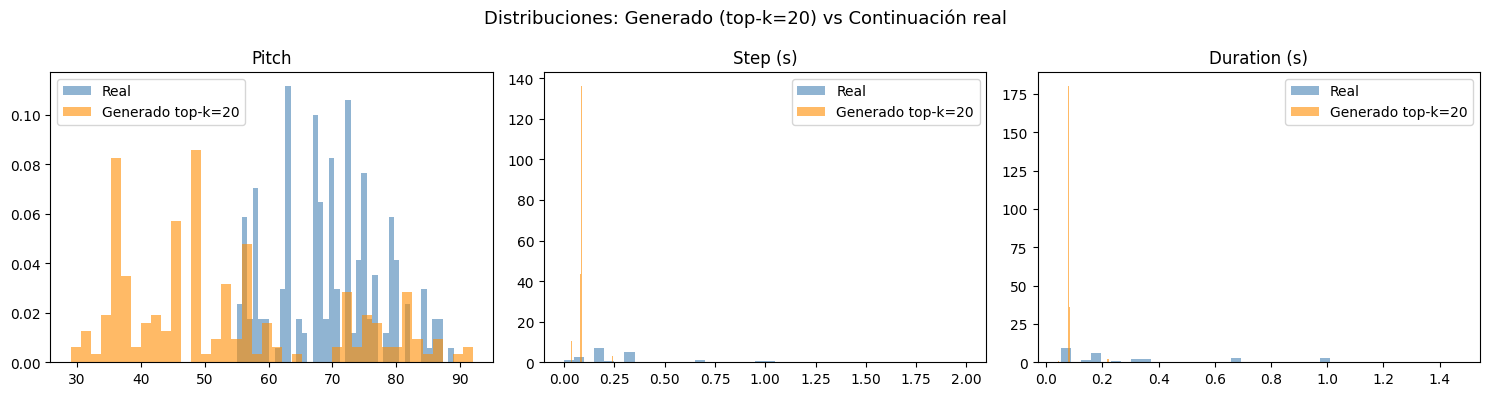

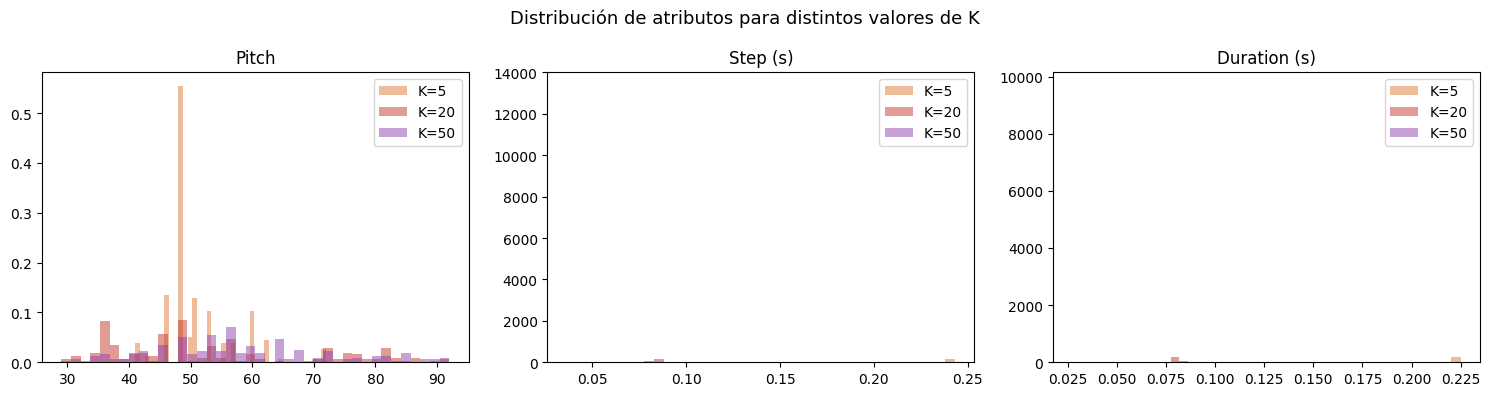

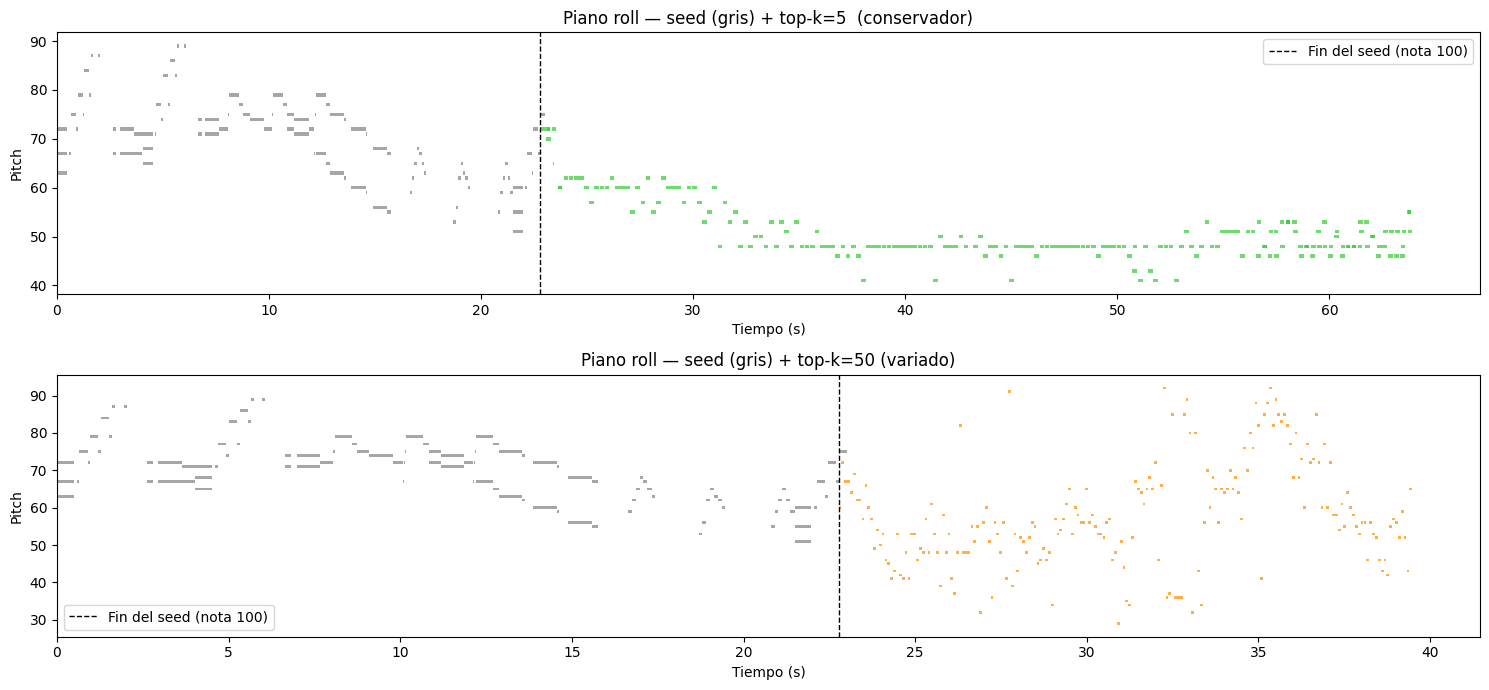

Step promedio real:       0.3069 s
Step promedio top-k=20:   0.0834 s
Ratio gen/real:           0.27x  <- mas rapido


In [36]:
# ── 14.1  Estadísticas: top-k=20 vs real ─────────────────────────────────
pm_topk = pretty_midi.PrettyMIDI(
    os.path.join(GENERATED_DIR, 'beethoven_1_4_topk_20.mid'))
notes_topk_raw = sorted(pm_topk.instruments[0].notes, key=lambda n: n.start)

rows_topk, prev_start = [], None
for n in notes_topk_raw:
    step = n.start - prev_start if prev_start is not None else 0.0
    rows_topk.append({'pitch': n.pitch, 'step': step,
                      'duration': n.end - n.start, 'velocity': n.velocity})
    prev_start = n.start
df_topk_eval = pd.DataFrame(rows_topk)

# Solo notas generadas (sin seed)
df_topk_only = df_topk_eval.iloc[BLOCK_SIZE:].reset_index(drop=True)

seq_real     = test_seqs[0].reset_index(drop=True)
df_real_seed = seq_real.iloc[:BLOCK_SIZE]
df_real_next = seq_real.iloc[BLOCK_SIZE : BLOCK_SIZE + 200].reset_index(drop=True)

n_topk = len(df_topk_only)
print(f'Notas generadas (top-k=20, sin seed): {n_topk}')
stats_topk = pd.DataFrame({
    'pitch_mean':    [df_topk_only['pitch'].mean(),    df_real_next['pitch'].mean()],
    'pitch_std':     [df_topk_only['pitch'].std(),     df_real_next['pitch'].std()],
    'step_mean':     [df_topk_only['step'].mean(),     df_real_next['step'].mean()],
    'step_std':      [df_topk_only['step'].std(),      df_real_next['step'].std()],
    'duration_mean': [df_topk_only['duration'].mean(), df_real_next['duration'].mean()],
    'velocity_mean': [df_topk_only['velocity'].mean(), df_real_next['velocity'].mean()],
}, index=['Generado (top-k=20)', 'Real (ref)']).T.round(4)
print('\nComparación estadística:')
print(stats_topk)

# ── 14.2  Distribuciones comparadas: top-k=20 vs real ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribuciones: Generado (top-k=20) vs Continuación real', fontsize=13)

for ax, col, label, clip_val in [
    (axes[0], 'pitch',    'Pitch',        None),
    (axes[1], 'step',     'Step (s)',      2.0),
    (axes[2], 'duration', 'Duration (s)', 2.0),
]:
    gen_vals  = df_topk_only[col].clip(0, clip_val)  if clip_val else df_topk_only[col]
    real_vals = df_real_next[col].clip(0, clip_val) if clip_val else df_real_next[col]
    ax.hist(real_vals, bins=40, alpha=0.6, label='Real',              density=True, color='steelblue')
    ax.hist(gen_vals,  bins=40, alpha=0.6, label='Generado top-k=20', density=True, color='darkorange')
    ax.set_title(label); ax.legend()

plt.tight_layout(); plt.show()

# ── 14.3  Comparación pitch entre distintos K ─────────────────────────────
colors_k = ['#e07b39', '#c0392b', '#8e44ad']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de atributos para distintos valores de K', fontsize=13)

for (tag, k), color in zip(topk_configs, colors_k):
    pm_k = pretty_midi.PrettyMIDI(os.path.join(GENERATED_DIR, f'beethoven_1_4_{tag}.mid'))
    nts  = sorted(pm_k.instruments[0].notes, key=lambda n: n.start)
    pitches = [n.pitch for n in nts[BLOCK_SIZE:]]
    steps   = np.clip([nts[i].start - nts[i-1].start
                       for i in range(BLOCK_SIZE + 1, len(nts))], 0, 2.0)
    durs    = np.clip([n.end - n.start for n in nts[BLOCK_SIZE:]], 0, 2.0)
    axes[0].hist(pitches, bins=40, alpha=0.5, label=f'K={k}', density=True, color=color)
    axes[1].hist(steps,   bins=40, alpha=0.5, label=f'K={k}', density=True, color=color)
    axes[2].hist(durs,    bins=40, alpha=0.5, label=f'K={k}', density=True, color=color)

for ax, title in zip(axes, ['Pitch', 'Step (s)', 'Duration (s)']):
    ax.set_title(title); ax.legend()

plt.tight_layout(); plt.show()

# ── 14.4  Piano roll: top-k=5 vs top-k=50 ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

def plot_roll_topk(ax, df, color, offset_t=0.0):
    t = offset_t
    for _, row in df.iterrows():
        t += row['step']
        ax.barh(row['pitch'], row['duration'], left=t, height=0.7,
                color=color, alpha=0.7)
    return t

seed_end = float(df_real_seed['step'].sum())

for ax, tag, k, color, label in [
    (axes[0], 'topk_5',  5,  'limegreen',  'top-k=5  (conservador)'),
    (axes[1], 'topk_50', 50, 'darkorange', 'top-k=50 (variado)'),
]:
    pm_k  = pretty_midi.PrettyMIDI(os.path.join(GENERATED_DIR, f'beethoven_1_4_{tag}.mid'))
    nts_k = sorted(pm_k.instruments[0].notes, key=lambda n: n.start)
    rws, prev = [], None
    for n in nts_k[BLOCK_SIZE:]:
        s = n.start - prev if prev is not None else 0.0
        rws.append({'pitch': n.pitch, 'step': s,
                    'duration': n.end - n.start, 'velocity': n.velocity})
        prev = n.start
    df_k = pd.DataFrame(rws)
    plot_roll_topk(ax, df_real_seed, 'gray')
    plot_roll_topk(ax, df_k, color, offset_t=seed_end)
    ax.axvline(seed_end, color='black', linestyle='--', lw=1,
               label=f'Fin del seed (nota {BLOCK_SIZE})')
    ax.set_title(f'Piano roll — seed (gris) + {label}')
    ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('Pitch')
    ax.legend()

plt.tight_layout(); plt.show()

ratio = (df_topk_only['step'].mean() / df_real_next['step'].mean()
         if df_real_next['step'].mean() > 0 else float('inf'))
step_real = df_real_next['step'].mean()
step_gen  = df_topk_only['step'].mean()
direction = 'mas rapido' if ratio < 1 else ('mas lento' if ratio > 1 else 'igual')
print(f'Step promedio real:       {step_real:.4f} s')
print(f'Step promedio top-k=20:   {step_gen:.4f} s')
print(f'Ratio gen/real:           {ratio:.2f}x  <- {direction}')


## 13. Visualización de embeddings de pitch — t-SNE

Los embeddings de pitch (vocab real, dimensión 16) se reducen a 2D con t-SNE.
Si el modelo aprendió estructura tonal, notas de la misma clase (Do en distintas
octavas) y grupos armónicos (Do-Mi-Sol) deberían quedar cerca.


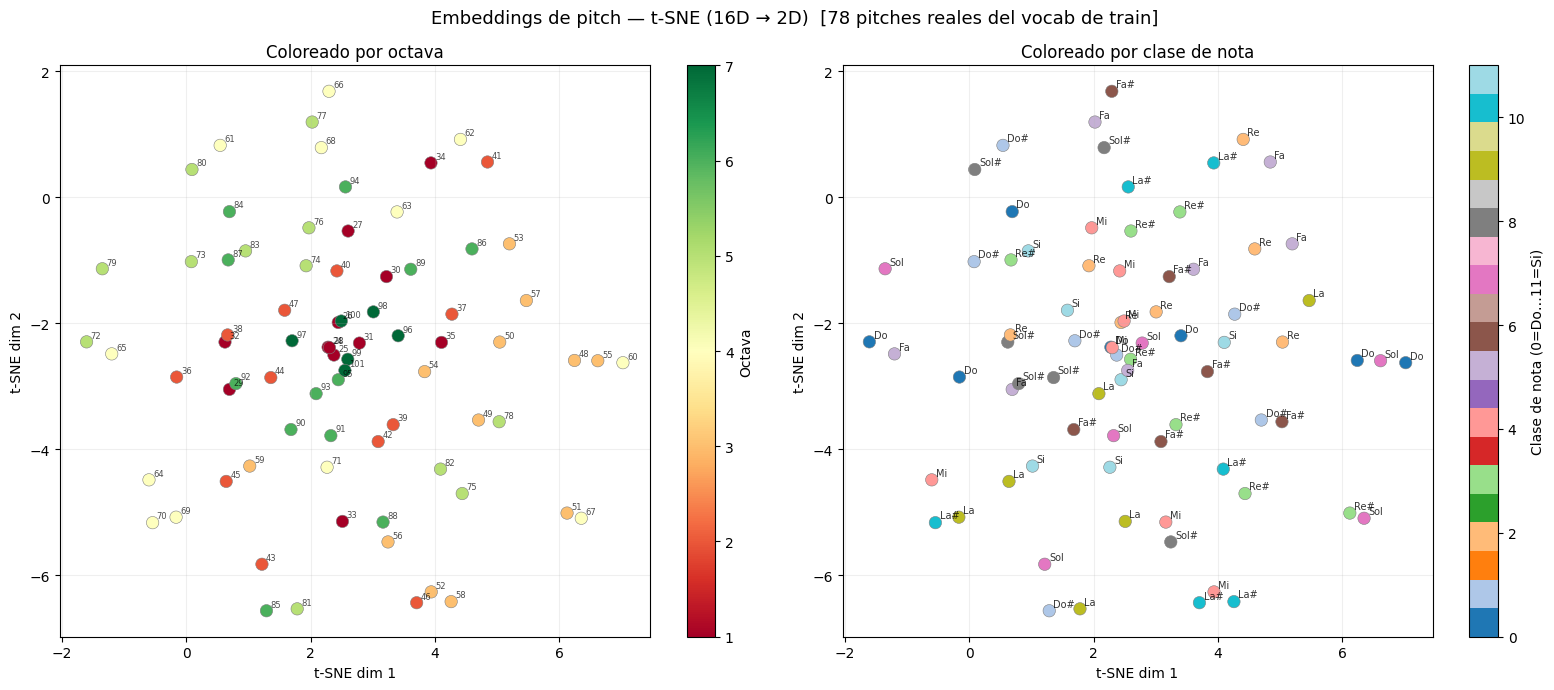

Qué buscar:
  → Notas de la misma clase (Do3, Do4, Do5…) agrupadas: el modelo capturó relaciones de octava.
  → Grupos armónicos cercanos (Do-Mi-Sol, Re-Fa#-La): el modelo aprendió acordes.
  → Si todo está mezclado: los embeddings no capturaron estructura tonal.


In [21]:
from sklearn.manifold import TSNE

# Extraer la matriz de embeddings entrenada: (PITCH_VOCAB_SIZE, 16)
emb_matrix = model.emb_pitch.weight.detach().cpu().numpy()

# Excluir el token UNK (último índice)
emb_known = emb_matrix[:UNK_PITCH_IDX]   # (V, 16)
pitches   = train_pitches                # lista de pitches reales (len=V)

tsne   = TSNE(n_components=2,
              perplexity=min(15, len(pitches) // 2),
              random_state=42, max_iter=1000)
emb_2d = tsne.fit_transform(emb_known)   # (V, 2)

NOTE_NAMES = ['Do','Do#','Re','Re#','Mi','Fa','Fa#','Sol','Sol#','La','La#','Si']
note_names = [NOTE_NAMES[p % 12] for p in pitches]
octaves    = [p // 12 - 1        for p in pitches]
chroma     = [p % 12             for p in pitches]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Embeddings de pitch — t-SNE (16D → 2D)  '
             f'[{len(pitches)} pitches reales del vocab de train]', fontsize=13)

# Plot 1: coloreado por octava
ax = axes[0]
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=octaves, cmap='RdYlGn', s=80, edgecolors='gray', lw=0.4)
for i, (x, y) in enumerate(emb_2d):
    ax.annotate(str(pitches[i]), (x, y), fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='Octava')
ax.set_title('Coloreado por octava')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2'); ax.grid(alpha=0.2)

# Plot 2: coloreado por clase de nota (Do, Re, Mi...)
ax = axes[1]
sc2 = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                 c=chroma, cmap='tab20', s=80, edgecolors='gray', lw=0.4)
for i, (x, y) in enumerate(emb_2d):
    ax.annotate(note_names[i], (x, y), fontsize=7, alpha=0.8,
                xytext=(3, 3), textcoords='offset points')
plt.colorbar(sc2, ax=ax, label='Clase de nota (0=Do…11=Si)')
ax.set_title('Coloreado por clase de nota')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2'); ax.grid(alpha=0.2)

plt.tight_layout(); plt.show()

print('Qué buscar:')
print('  → Notas de la misma clase (Do3, Do4, Do5…) agrupadas: '
      'el modelo capturó relaciones de octava.')
print('  → Grupos armónicos cercanos (Do-Mi-Sol, Re-Fa#-La): el modelo aprendió acordes.')
print('  → Si todo está mezclado: los embeddings no capturaron estructura tonal.')


In [22]:
import requests

requests.post(
    'https://ntfy.sh/MAIA_NLP_1_2026_SEBASTIAN',
    data='Modelo 1_4 finalizado',
    headers={'Title': 'MAIA NLP - MusicLSTM v4'}
)


<Response [200]>